Attention output: torch.Size([2, 8, 5, 64])
Weights sum (should be 1.0): 1.0000
Dataset: 1,115,394 characters
Vocabulary: 65 unique characters

Loading existing checkpoint...

GPT-2 initialised | Parameters: 816,512
Checkpoint loaded successfully.
Training on: cuda
Dataset: 1,115,394 characters
Vocabulary: 65 unique characters
Using existing model from checkpoint.
Step    0 | Train loss: 1.8156 | Val loss: 1.8325 | LR: 3.00e-06
Step  300 | Train loss: 1.7681 | Val loss: 1.8207 | LR: 2.96e-04
Step  600 | Train loss: 1.7105 | Val loss: 1.7837 | LR: 2.78e-04
Step  900 | Train loss: 1.6729 | Val loss: 1.7499 | LR: 2.47e-04
Step 1200 | Train loss: 1.6510 | Val loss: 1.7236 | LR: 2.05e-04
Step 1500 | Train loss: 1.6154 | Val loss: 1.7046 | LR: 1.58e-04
Step 1800 | Train loss: 1.6057 | Val loss: 1.6804 | LR: 1.10e-04
Step 2100 | Train loss: 1.5990 | Val loss: 1.6773 | LR: 6.57e-05
Step 2400 | Train loss: 1.5527 | Val loss: 1.6804 | LR: 3.05e-05
Step 2700 | Train loss: 1.5410 | Val loss: 1.661

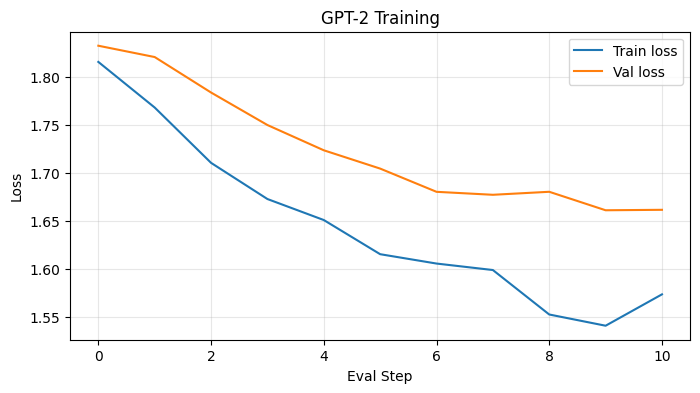


--- Generating from: 'HAMLET:
' ---
HAMLET:
The are their fiends; and ever mine to himself.

EDWARD:
I am any from this deign,
Therefore's of stand like to thy trust,
I say the too: brother runge crown, that I speak you,
Heaven you breather world soul and state the shall have
Be I do, and for grace! and the sozered,
What my provice to Ded Rom


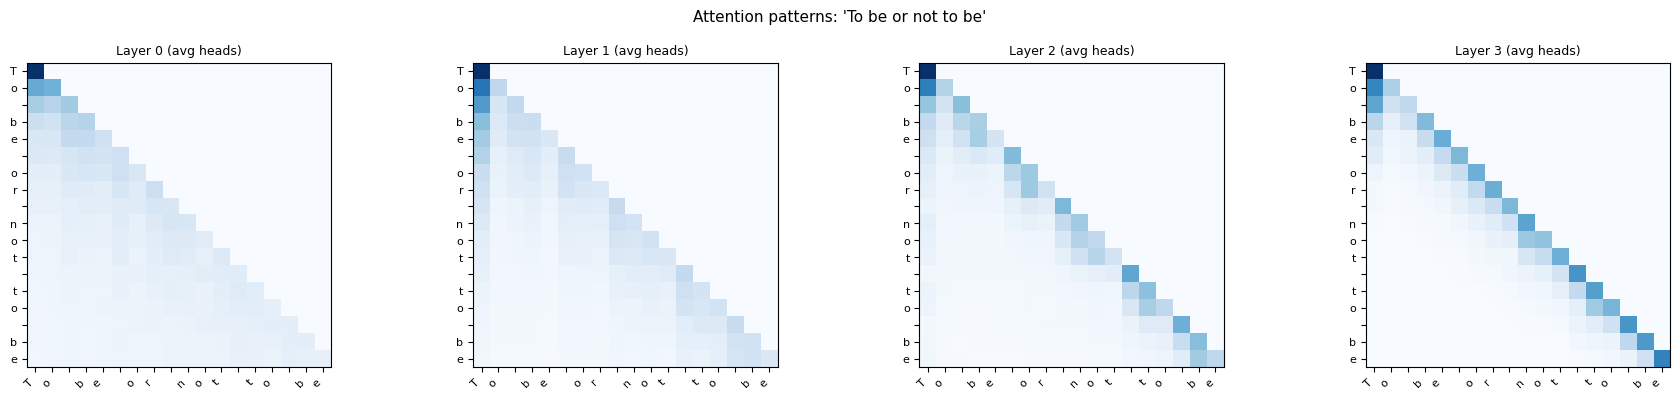

Attention maps saved.


CHAT MODE
 *** Type 'exit' to quit. ***



You:  When winter leaves the



--- Generating from: 'When winter leaves the' ---
When winter leaves the well from the worshing.

ELBOW:
Shall you, have a break wantled for to our,
And cread-take of this, and the so cherse before
The learn of expose to him.

Shepherd:
How your man, on lord forth soons, 

Model:
When winter leaves the well from the worshing.

ELBOW:
Shall you, have a break wantled for to our,
And cread-take of this, and the so cherse before
The learn of expose to him.

Shepherd:
How your man, on lord forth soons, 



You:  Purple dragons sing beneath



--- Generating from: 'Purple dragons sing beneath' ---
Purple dragons sing beneath.
My some why, the pray thy habed not tale
It to speak the sits of with his do prence
You so be in the stone of a some royal of
The cannother, both so no crail'd your lives,
And a queen can the good w

Model:
Purple dragons sing beneath.
My some why, the pray thy habed not tale
It to speak the sits of with his do prence
You so be in the stone of a some royal of
The cannother, both so no crail'd your lives,
And a queen can the good w


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass


def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    The core attention equation:
        Attention(Q, K, V) = softmax( Q @ Kᵀ / √d_k ) @ V

    Args:
        Q    : [B, n_heads, T, d_k]   — Queries
        K    : [B, n_heads, T, d_k]   — Keys
        V    : [B, n_heads, T, d_v]   — Values
        mask : [B, 1, T, T] or None   — True where we should BLOCK attention

    Returns:
        output : [B, n_heads, T, d_v]
        weights: [B, n_heads, T, T]   — attention distribution (for visualisation)
    """
    d_k = Q.size(-1)   # head dimension, e.g. 64 for GPT-2 small

    # Step 1: Compute raw attention scores
    # Q @ Kᵀ → [B, n_heads, T, T]
    # Each cell [b, h, i, j] = how much token i attends to token j
    scores = Q @ K.transpose(-2, -1)   # [B, H, T, T]

    # Step 2: Scale by √d_k
    # WHY: dot products grow large in high dimensions (variance ∝ d_k).
    # Large scores → softmax saturates → gradients vanish.
    # Dividing by √d_k keeps the variance at ~1 regardless of d_k.
    scores = scores / math.sqrt(d_k)   # [B, H, T, T]

    # Step 3: Apply causal mask (decoder / GPT only)
    # The mask is True where attention is FORBIDDEN (future tokens).
    # We fill those positions with -infinity so softmax makes them 0.
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    # Step 4: Softmax over the last dim (keys dimension)
    # Converts raw scores → probability distribution for each query.
    # Each row of [T, T] sums to 1.
    weights = F.softmax(scores, dim=-1)   # [B, H, T, T]

    # Step 5: Weighted sum of Values
    # Each token gets a blend of all Values, weighted by attention.
    output = weights @ V   # [B, H, T, d_v]

    return output, weights


#  Quick sanity check
def test_attention():
    B, T, d_k = 2, 5, 64
    H = 8
    Q = torch.randn(B, H, T, d_k)
    K = torch.randn(B, H, T, d_k)
    V = torch.randn(B, H, T, d_k)
    out, w = scaled_dot_product_attention(Q, K, V)
    print(f"Attention output: {out.shape}")   # [2, 8, 5, 64]
    print(f"Weights sum (should be 1.0): {w[0,0,0].sum():.4f}")



#CAUSAL MASK
# GPT is autoregressive: at position t, it can only see tokens 0…t-1.
# We enforce this with an upper-triangular mask of True values.
# softmax(-inf) = 0, so masked positions contribute nothing.

def make_causal_mask(T: int, device: torch.device) -> torch.Tensor:
    """
    Returns an upper-triangular boolean mask of shape [1, 1, T, T].
    True = this position is masked (forbidden to attend to).

    For T=4, the mask looks like:
        [[False  True  True  True],
         [False False  True  True],
         [False False False  True],
         [False False False False]]

    Token 0 sees only itself.
    Token 3 sees tokens 0, 1, 2, 3.
    """
    # torch.triu with diagonal=1 keeps the upper triangle (above diagonal)
    mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=device),
                      diagonal=1)
    return mask.unsqueeze(0).unsqueeze(0)   # [1, 1, T, T]



# MULTI-HEAD ATTENTION


class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention (or cross-attention if kv_input provided).

    d_model  : total model dimension (e.g. 768 for GPT-2 small)
    n_heads  : number of attention heads (e.g. 12)
    d_k = d_v = d_model // n_heads  = 64 for GPT-2 small
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads   # per-head dimension

        # Three linear projections: X → Q, K, V
        # We use a single matrix for Q and a single matrix for K, V
        # (or all three separate — both work, this is cleaner)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)

        # Output projection: concatenated heads → d_model
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, kv_input=None, mask=None):
        """
        x        : [B, T, d_model]  — query input
        kv_input : [B, S, d_model]  — key/value input (cross-attention)
                   if None, uses x (self-attention)
        mask     : causal or padding mask

        Self-attention:    kv_input=None  → Q, K, V all from x
        Cross-attention:   kv_input≠None  → Q from x, K/V from kv_input
        """
        B, T, _ = x.shape
        kv = kv_input if kv_input is not None else x
        S  = kv.size(1)   # source length (= T for self-attention)

        # Project to Q, K, V
        # [B, T, d_model] → [B, T, d_model]
        Q = self.W_q(x)
        K = self.W_k(kv)
        V = self.W_v(kv)

        # Reshape into heads
        # [B, T, d_model] → [B, T, n_heads, d_k] → [B, n_heads, T, d_k]
        # This is just a view — no data is copied.
        # We're splitting the d_model dimension into n_heads × d_k.
        Q = Q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(B, S, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(B, S, self.n_heads, self.d_k).transpose(1, 2)
        # Shapes: [B, n_heads, T, d_k]

        # Run attention on all heads in parallel
        attn_out, weights = scaled_dot_product_attention(Q, K, V, mask)
        # attn_out: [B, n_heads, T, d_k]

        # Concatenate heads 
        # [B, n_heads, T, d_k] → [B, T, n_heads, d_k] → [B, T, d_model]
        # contiguous() needed before view when tensor is transposed
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, self.d_model)

        # Output projection
        output = self.W_o(attn_out)   # [B, T, d_model]
        output = self.dropout(output)

        return output, weights   # return weights for visualisation



#FEED-FORWARD BLOCK (MLP)

# After attention, every position goes through an identical MLP.
# This is where the model stores "facts" — attention routes information,
# the MLP processes and stores it.
#
# Size: 4 × d_model (GPT-2: 768 → 3072 → 768)
# Activation: GELU (smoother ReLU — used in all modern transformers)

class FeedForward(nn.Module):
    """
    Position-wise feed-forward network.
    Applied identically to every token position independently.
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        # d_ff is typically 4 × d_model (from the original paper)
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),          # GELU ≈ x * Φ(x), smoother than ReLU
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: [B, T, d_model] → [B, T, d_model]
        # Each token transformed independently — no cross-token mixing here
        return self.net(x)



# TRANSFORMER BLOCK  (the repeating unit)
# One transformer block = Attention + FFN + two residuals + two LayerNorms.
#
# PRE-NORM (modern, what we use):
#   x = x + Attention(LayerNorm(x))
#   x = x + FFN(LayerNorm(x))
#
# POST-NORM (original 2017 paper):
#   x = LayerNorm(x + Attention(x))
#   x = LayerNorm(x + FFN(x))
#
# WHY PRE-NORM?
# At initialisation, LayerNorm(x) ≈ x (scale=1, bias=0 by default).
# This means the residual path x + Attention(LayerNorm(x)) starts as
# x + small_noise, keeping gradients stable from the first step.
# Post-norm forces gradients through LayerNorm at the bottom of the
# residual, causing gradient explosion/vanishing in deep models.
# ALL modern LLMs (GPT-2+, LLaMA, Mistral) use Pre-norm.

class TransformerBlock(nn.Module):
    """
    One GPT-2 transformer block:
        x → LayerNorm → MultiHeadAttention → + residual
          → LayerNorm → FeedForward         → + residual
    """
    def __init__(self, d_model: int, n_heads: int,
                 d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, mask=None):
        #Pre-norm attention with residual
        # LayerNorm FIRST, then attention, then ADD back to original x
        attn_out, weights = self.attn(self.ln1(x), mask=mask)
        x = x + attn_out          # residual connection

        #Pre-norm FFN with residual
        x = x + self.ff(self.ln2(x))   # residual connection

        return x, weights



# SINUSOIDAL POSITIONAL ENCODING (original paper)

# Transformers have no built-in sense of order — attention treats
# all positions equally. We inject position information by adding
# a fixed vector to each token embedding.
#
# Formula:
#   PE[pos, 2i]   = sin(pos / 10000^(2i/d_model))
#   PE[pos, 2i+1] = cos(pos / 10000^(2i/d_model))
#
# Why does this work?
#   For any fixed offset k, PE[pos+k] can be expressed as a linear
#   function of PE[pos]. So the model can learn "token at relative
#   offset +3" just by learning a linear transformation — positions
#   are represented in a way that makes relative distances learnable.

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the PE table once — it never changes (not learned)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()   # [max_len, 1]
        # Division term: 1 / 10000^(2i/d_model)
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)   # even dims → sin
        pe[:, 1::2] = torch.cos(pos * div)   # odd dims  → cos

        # Register as buffer: saved with model, moves to GPU,
        # but NOT a learned parameter (no gradient)
        self.register_buffer('pe', pe.unsqueeze(0))   # [1, max_len, d_model]

    def forward(self, x):
        # x: [B, T, d_model]
        # pe[:, :T]: take only the first T position vectors
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)



# ROPE: ROTARY POSITIONAL ENCODING

# Used in: LLaMA, Mistral, Gemma, Qwen, and most modern LLMs.
# Key advantage: encodes RELATIVE positions, not absolute.
# The attention score between tokens i and j depends only on (i - j),
# not on their absolute positions. This generalises better to
# sequences longer than those seen during training.
#
# How it works:
#   Instead of adding position vectors, we ROTATE Q and K vectors
#   in 2D planes by an angle proportional to their position.
#   When we compute Q·K^T, the angle difference = relative position.

def precompute_rope_frequencies(d_k: int, max_len: int,
                                 base: float = 10000.0):
    """
    Precompute the rotation frequencies for RoPE.
    Returns cos and sin tables of shape [max_len, d_k].
    """
    # Frequency for each dimension pair
    theta = 1.0 / (base ** (torch.arange(0, d_k, 2).float() / d_k))
    # [d_k/2]

    positions = torch.arange(max_len).float()   # [max_len]
    # Outer product: [max_len, d_k/2]
    freqs = torch.outer(positions, theta)

    # [max_len, d_k]: repeat each frequency for both sin and cos dims
    freqs = torch.cat([freqs, freqs], dim=-1)
    return freqs.cos(), freqs.sin()   # both [max_len, d_k]


def apply_rope(x, cos, sin):
    """
    Apply rotary position embedding to Q or K.
    x   : [B, n_heads, T, d_k]
    cos, sin: [T, d_k]
    """
    # Split x into two halves — we rotate pairs of dimensions
    d_k = x.size(-1)
    x1  = x[..., :d_k // 2]   # first half
    x2  = x[..., d_k // 2:]   # second half

    # Rotate: [x1, x2] → [-x2, x1] (90° rotation in each 2D plane)
    x_rotated = torch.cat([-x2, x1], dim=-1)

    # Broadcast cos/sin from [T, d_k] to [B, n_heads, T, d_k]
    cos = cos[:x.size(2)].unsqueeze(0).unsqueeze(0)
    sin = sin[:x.size(2)].unsqueeze(0).unsqueeze(0)

    return x * cos + x_rotated * sin



#  FULL GPT-2 MODEL

# GPT-2 architecture:
#   Token embedding + Positional embedding (learned in original GPT-2)
#   → N × TransformerBlock
#   → Final LayerNorm
#   → Linear head (d_model → vocab_size)
#   → Logits (one per vocabulary token)

@dataclass
class GPTConfig:
    vocab_size  : int   = 50257    # GPT-2 vocabulary size
    max_len     : int   = 1024     # maximum sequence length
    d_model     : int   = 768      # embedding dimension
    n_layers    : int   = 12       # number of transformer blocks
    n_heads     : int   = 12       # number of attention heads
    d_ff        : int   = 3072     # FFN hidden dimension (4 × d_model)
    dropout     : float = 0.1
    # Tiny config for training on CPU/small GPU:
    # d_model=128, n_layers=4, n_heads=4, d_ff=512


class GPT2(nn.Module):
    """
    GPT-2 language model — decoder-only transformer.
    Trained to predict the next token given all previous tokens.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            # Token embedding: integer index → d_model vector
            tok_emb = nn.Embedding(config.vocab_size, config.d_model),

            # Positional embedding: GPT-2 uses LEARNED positional embeddings
            # (not sinusoidal). Just another Embedding table over positions.
            pos_emb = nn.Embedding(config.max_len, config.d_model),

            drop    = nn.Dropout(config.dropout),

            # N transformer blocks
            blocks  = nn.ModuleList([
                TransformerBlock(config.d_model, config.n_heads,
                                 config.d_ff, config.dropout)
                for _ in range(config.n_layers)
            ]),

            # Final LayerNorm before the output head
            ln_f    = nn.LayerNorm(config.d_model),
        ))

        # Language model head: d_model → vocab_size
        # This converts the final hidden state to logits over vocabulary.
        # NOTE: GPT-2 TIES weights — tok_emb and lm_head share the same matrix.
        # This reduces parameters and improves training stability.
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)
        self.lm_head.weight = self.transformer.tok_emb.weight  # weight tying

        # Initialise weights properly
        self.apply(self._init_weights)

        total = sum(p.numel() for p in self.parameters())
        print(f"GPT-2 initialised | Parameters: {total:,}")

    def _init_weights(self, module):
        """
        Careful initialisation is critical for transformer training.
        Linear layers: N(0, 0.02) — small std prevents early saturation.
        Embeddings: same.
        Residual projections: scale by 1/√(2 × n_layers) to keep
        activations stable at initialisation (GPT-2 paper).
        """
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        idx     : [B, T]  — token indices
        targets : [B, T]  — next token targets (for training)

        Returns:
            logits : [B, T, vocab_size]
            loss   : scalar CrossEntropyLoss if targets provided, else None
        """
        B, T = idx.shape
        device = idx.device

        assert T <= self.config.max_len, \
            f"Sequence length {T} exceeds max_len {self.config.max_len}"

        #Token + position embeddings 
        tok = self.transformer.tok_emb(idx)   # [B, T, d_model]

        # Position indices: [0, 1, 2, ..., T-1] for every item in batch
        pos_idx = torch.arange(T, device=device).unsqueeze(0)  # [1, T]
        pos = self.transformer.pos_emb(pos_idx)   # [1, T, d_model]

        x = self.transformer.drop(tok + pos)   # [B, T, d_model]

        #Causal mask 
        mask = make_causal_mask(T, device)   # [1, 1, T, T]

        # N transformer blocks 
        for block in self.transformer.blocks:
            x, _ = block(x, mask=mask)   # [B, T, d_model]

        #  Final LayerNorm 
        x = self.transformer.ln_f(x)   # [B, T, d_model]

        # Language model head 
        logits = self.lm_head(x)   # [B, T, vocab_size]

        #Loss (training only)
        loss = None
        if targets is not None:
            # Reshape for CrossEntropyLoss:
            # [B, T, vocab_size] → [B*T, vocab_size]
            # [B, T]             → [B*T]
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss



# DATA: TINY SHAKESPEARE

def get_shakespeare_data(block_size=128):
    """Download and tokenise tiny Shakespeare dataset."""
    import urllib.request

    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    urllib.request.urlretrieve(url, "shakespeare.txt")

    with open("shakespeare.txt", "r") as f:
        text = f.read()

    print(f"Dataset: {len(text):,} characters")

    # Character-level tokenisation (simple, no tiktoken needed)
    chars    = sorted(set(text))
    vocab_size = len(chars)
    print(f"Vocabulary: {vocab_size} unique characters")

    stoi = {c: i for i, c in enumerate(chars)}   # char → int
    itos = {i: c for i, c in enumerate(chars)}   # int → char

    encode = lambda s: [stoi[c] for c in s]
    decode = lambda l: ''.join([itos[i] for i in l])

    data = torch.tensor(encode(text), dtype=torch.long)

    # Train/val split
    n = int(0.9 * len(data))
    train_data = data[:n]
    val_data   = data[n:]

    return train_data, val_data, vocab_size, encode, decode


def get_batch(data, block_size, batch_size, device):
    """
    Sample a random batch of (inputs, targets) from data.
    inputs : [B, block_size]  — token indices
    targets: [B, block_size]  — same tokens shifted by 1

    For input  [t0, t1, t2, ..., tN-1]
    targets is [t1, t2, t3, ..., tN]
    The model predicts each next token from all previous tokens.
    """
    # Random starting positions
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x  = torch.stack([data[i    : i + block_size    ] for i in ix])
    y  = torch.stack([data[i + 1: i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)



# TRAINING LOOP


def train_gpt(config: GPTConfig, steps=3000, eval_interval=300,
              batch_size=32, block_size=128, model=None):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    train_data, val_data, vocab_size, encode, decode = \
        get_shakespeare_data(block_size)

    config.vocab_size = vocab_size
    config.max_len    = block_size

    # Only build a fresh model if none was passed in
    if model is None:
        model = GPT2(config).to(device)
        print("Created new model.")
    else:
        model = model.to(device)
        print("Using existing model from checkpoint.")

    

    # AdamW with weight decay (preferred over Adam for transformers)
    # Weight decay regularises all non-bias, non-LayerNorm parameters.
    optimizer = optim.AdamW(
        model.parameters(), lr=3e-4, weight_decay=0.1
    )

    # Cosine LR schedule with warmup
    # Warmup: linear increase from 0 → max_lr over warmup_steps
    # Prevents large gradient updates before embeddings have warmed up
    warmup_steps = 100
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps            # linear warmup
        # Cosine decay after warmup
        progress = (step - warmup_steps) / max(1, steps - warmup_steps)
        return max(0.1, 0.5 * (1 + math.cos(math.pi * progress)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    train_losses, val_losses = [], []
    best_val = float('inf')

    model.train()
    for step in range(steps):
        xb, yb = get_batch(train_data, block_size, batch_size, device)

        _, loss = model(xb, yb)
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping: caps gradient norm at 1.0
        # Transformers can have explosive gradients — this is standard.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        if step % eval_interval == 0 or step == steps - 1:
            model.eval()
            with torch.no_grad():
                # Estimate val loss over multiple batches
                val_loss = sum(
                    model(*get_batch(val_data, block_size, batch_size, device))[1].item()
                    for _ in range(20)
                ) / 20

            train_losses.append(loss.item())
            val_losses.append(val_loss)
            lr = optimizer.param_groups[0]['lr']
            print(f"Step {step:4d} | Train loss: {loss.item():.4f} "
                  f"| Val loss: {val_loss:.4f} | LR: {lr:.2e}")

            if val_loss < best_val:
                best_val = val_loss
                torch.save(model.state_dict(), "gpt2_shakespeare.pth")

            model.train()

    return model, encode, decode, train_losses, val_losses



# TEXT GENERATION

# Temperature controls randomness:
#   temperature < 1 → sharper distribution, more conservative
#   temperature > 1 → flatter distribution, more creative
#   temperature = 0 → always pick the top token (greedy)
#
# Top-k sampling: only sample from the k most likely tokens.
# Prevents the model from accidentally picking very unlikely tokens.

@torch.no_grad()
def generate(model, encode, decode, prompt="O Romeo",
             max_new_tokens=200, temperature=0.8, top_k=40):
    """
    Autoregressive text generation:
    Feed prompt → get logits → sample next token → append → repeat
    """
    model.eval()
    device = next(model.parameters()).device

    # Encode prompt to token indices
    idx = torch.tensor(encode(prompt), dtype=torch.long,
                       device=device).unsqueeze(0)   # [1, T]

    print(f"\n--- Generating from: '{prompt}' ---")

    for _ in range(max_new_tokens):
        # Crop to max context window
        idx_cond = idx[:, -model.config.max_len:]

        # Forward pass → logits for the last position
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]   # [1, vocab_size] — last token only

        # Apply temperature
        logits = logits / temperature

        # Top-k: zero out all logits outside the top-k
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        # Sample from the distribution
        probs   = F.softmax(logits, dim=-1)
        next_tok = torch.multinomial(probs, num_samples=1)   # [1, 1]

        # Append sampled token and continue
        idx = torch.cat([idx, next_tok], dim=1)

    generated_text = decode(idx[0].tolist())
    print(generated_text)
    return generated_text



# ATTENTION VISUALISATION



def visualise_attention(model, encode, decode, text="To be or not to be"):
    model.eval()
    device = next(model.parameters()).device
    tokens = encode(text)
    idx = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)
    chars = [decode([t]) for t in tokens]

    # Forward pass — collect attention weights from ALL blocks
    tok = model.transformer.tok_emb(idx)
    pos_idx = torch.arange(idx.size(1), device=device).unsqueeze(0)
    pos = model.transformer.pos_emb(pos_idx)
    x = tok + pos
    mask = make_causal_mask(idx.size(1), device)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    block_indices = [0, 1, model.config.n_layers//2, model.config.n_layers-1]

    for ax_idx, block_i in enumerate(block_indices):
        with torch.no_grad():
            for i, block in enumerate(model.transformer.blocks):
                _, weights = block(x, mask=mask)
                if i == block_i:
                    # Average across heads: [B, n_heads, T, T] → [T, T]
                    attn_map = weights[0].mean(0).cpu().numpy()
                    break
                x, _ = block(x, mask=mask)

        ax = axes[ax_idx]
        ax.imshow(attn_map, cmap='Blues', vmin=0, vmax=attn_map.max())
        ax.set_xticks(range(len(chars)))
        ax.set_yticks(range(len(chars)))
        ax.set_xticklabels(chars, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(chars, fontsize=8)
        ax.set_title(f"Layer {block_i} (avg heads)", fontsize=9)

    plt.suptitle(f"Attention patterns: '{text}'", fontsize=11)
    plt.tight_layout()
    plt.savefig("attention_maps.png", dpi=150)
    plt.show()
    print("Attention maps saved.")



import os

if __name__ == "__main__":

    
    test_attention()

    checkpoint_path = "gpt2_shakespeare.pth"


    config = GPTConfig(
        d_model  = 128,
        n_layers = 4,
        n_heads  = 4,
        d_ff     = 512,
        dropout  = 0.1,
    )

   
    train_data, val_data, vocab_size, encode, decode = \
        get_shakespeare_data(block_size=128)

    config.vocab_size = vocab_size
    config.max_len = 128

   
    if os.path.exists(checkpoint_path):

        print("\nLoading existing checkpoint...\n")

        model = GPT2(config)

        model.load_state_dict(
            torch.load(
                checkpoint_path,
                map_location="cpu"
            )
        )

        print("Checkpoint loaded successfully.")

    else:

        print("\nNo checkpoint found.")
        print("Starting training from scratch.\n")

        model = None

    
    model, encode, decode, t_losses, v_losses = train_gpt(
        config,
        model=model,
        steps=3000,
        eval_interval=300,
        batch_size=64,
        block_size=128,
    )

    
    plt.figure(figsize=(8, 4))

    plt.plot(t_losses,
             label='Train loss')

    plt.plot(v_losses,
             label='Val loss')

    plt.title("GPT-2 Training")
    plt.xlabel("Eval Step")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.savefig("gpt2_training.png", dpi=150)
    plt.show()

    
    generate(
        model,
        encode,
        decode,
        prompt="HAMLET:\n",
        max_new_tokens=300,
        temperature=0.8
    )

   
    visualise_attention(
        model,
        encode,
        decode,
        text="To be or not to be"
    )

   
    print("\n")
    print("CHAT MODE")
    print(" *** Type 'exit' to quit. ***")
  

    while True:

        prompt = input("\nYou: ")

        if prompt.lower() in ["exit", "quit"]:
            print("Goodbye.")
            break

        response = generate(
            model,
            encode,
            decode,
            prompt=prompt,
            max_new_tokens=200,
            temperature=0.8,
            top_k=40
        )

        print("\nModel:")
        print(response)   
 



